In [1]:
%cd ../../

/leonardo_work/IscrC_LR4LSDS/encoderops


In [2]:
import torch
from dotenv import load_dotenv
from pathlib import Path
from src.model import EvolutionOperator
from src.data import DESRESDataModule
from src.configs import TrainerArgs, DESRESDataArgs # noqa
from huggingface_hub import hf_hub_download
from torch_geometric.loader import DataLoader
from loguru import logger
# from dataclasses import asdict
# import linear_operator_learning as lol
import matplotlib.pyplot as plt
#from src.data import mdtraj_load
import numpy as np
import os
#from src.utils import compute_descriptors
import pandas as pd
# import wandb

# Assume there's a .env file on the root of the repo where "DATA_PATH" is defined
load_dotenv()

True

In [30]:
baseline_runs: dict[str, str] = {
    "l2_jeong": "ri2xdor0",
    "dpnets_jeong": "jrrv6r59",
    "vampnets_jeong": "zgh4xh6a",
    "joint_l2_jeong": "2j4k7wf7",
    "seq_l2_jeong": "h4np95x4",
    "l2": "9dgu7e6f",
    "dpnets": "1104ltut",
    "vampnets": "oy1cfh9i",
    "joint_l2": "03lvauoh",
    "seq_l2": "860pfnf9",
}

In [31]:
ckpt_path = lambda baseline: Path(f"logs/encoderops-2JOF/{baseline_runs[baseline]}/checkpoints/last.ckpt")

In [32]:
@torch.no_grad()
def get_timescales(baseline):
    print(f"Retrieving {baseline}")
    model = EvolutionOperator.load_from_checkpoint(ckpt_path(baseline))
    lagtime_ns = 100
    transfer_operator = model.get_transfer_operator()
    operator_eigs = torch.linalg.eigvals(transfer_operator).numpy(force=True)
    timescales = np.sort((1 / -np.log(np.abs(operator_eigs))) * lagtime_ns)[::-1]
    return timescales

In [49]:
timescales = {k: get_timescales(k) for k in baseline_runs.keys()}

Retrieving l2_jeong
Retrieving dpnets_jeong
Retrieving vampnets_jeong
Retrieving joint_l2_jeong
Retrieving seq_l2_jeong
Retrieving l2
Retrieving dpnets
Retrieving vampnets
Retrieving joint_l2
Retrieving seq_l2


In [50]:
palettes = {
    "categorical_light": [
        "#6929c4",
        "#1192e8",
        "#005d5d",
        "#9f1853",
        "#fa4d56",
        "#570408",
        "#198038",
        "#002d9c",
        "#ee538b",
        "#b28600",
        "#009d9a",
        "#012749",
        "#8a3800",
        "#a56eff",
    ],
    "categorical_dark": [
        "#8a3ffc",
        "#33b1ff",
        "#007d79",
        "#ff7eb6",
        "#fa4d56",
        "#fff1f1",
        "#6fdc8c",
        "#4589ff",
        "#d12771",
        "#d2a106",
        "#08bdba",
        "#bae6ff",
        "#ba4e00",
        "#d4bbff",
    ],
    "sequential_blue": [
        "#edf5ff",
        "#d0e2ff",
        "#a6c8ff",
        "#78a9ff",
        "#4589ff",
        "#0f62fe",
        "#0043ce",
        "#002d9c",
        "#001d6c",
        "#001141",
    ],
    "sequential_purple": [
        "#f6f2ff",
        "#e8daff",
        "#d4bbff",
        "#be95ff",
        "#a56eff",
        "#8a3ffc",
        "#6929c4",
        "#491d8b",
        "#31135e",
        "#1c0f30",
    ],
    "sequential_cyan": [
        "#e5f6ff",
        "#bae6ff",
        "#82cfff",
        "#33b1ff",
        "#1192e8",
        "#0072c3",
        "#00539a",
        "#003a6d",
        "#012749",
        "#1c0f30",
    ],
    "sequential_teal": [
        "#d9fbfb",
        "#9ef0f0",
        "#3ddbd9",
        "#08bdba",
        "#009d9a",
        "#007d79",
        "#005d5d",
        "#004144",
        "#022b30",
        "#081a1c",
    ],
    "pastel": [
        "#fd7f6f",
        "#7eb0d5",
        "#b2e061",
        "#bd7ebe",
        "#ffb55a",
        "#ffee65",
        "#beb9db",
        "#fdcce5",
        "#8bd3c7",
    ],
    "bright": [
        "#e60049",
        "#0bb4ff",
        "#50e991",
        "#e6d800",
        "#9b19f5",
        "#ffa300",
        "#dc0ab4",
        "#b3d4ff",
        "#00bfa0",
    ],
}

/scratch_local/ipykernel_3839361/3011548561.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, ts, '.-', label = k, c = color, linestyle=linestyle)


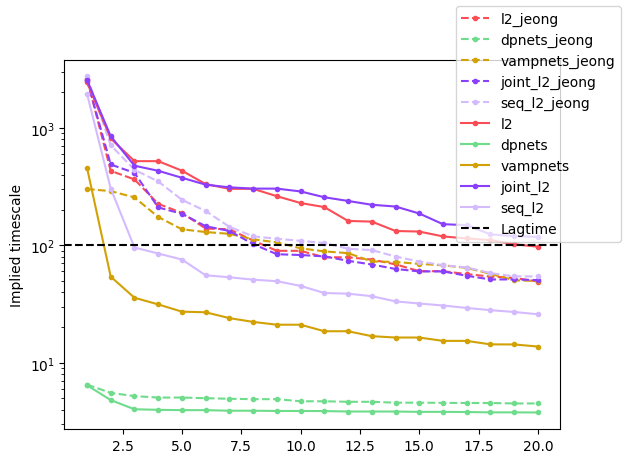

In [51]:
color_dict = {
    "l2": 4,
    "vampnets": 9,
    "dpnets": 6,
    "seq_l2": 13,
    "joint_l2": 0
}
fig, ax = plt.subplots()
for k, ts in timescales.items():
    ts = ts[:20]
    is_jeong = 'jeong' in k
    name = k[:-6] if is_jeong else k
    x = range(1, len(ts) + 1)
    color = palettes['categorical_dark'][color_dict[name]]
    linestyle = '--' if is_jeong else '-' 
    ax.plot(x, ts, '.-', label = k, c = color, linestyle=linestyle)
ax.set_yscale('log')
ax.set_ylabel('Implied timescale')
ax.axhline(y=100, color='k', linestyle='--', label="Lagtime")
fig.legend()